#### Linear Regression with Scikit

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, r2_score


data = pd.read_csv("scikit_housing_data.csv")
print(data.head())


   bedrooms  bathrooms  sqft_living  age   price  year_built
0         3          2         1800   15  350000        2009
1         4          3         2200   10  450000        2014
2         2          1         1400   25  300000        1999
3         3          2         2000   20  375000        2004
4         5          4         3000    5  600000        2019


#### EDA of the Data

        bedrooms  bathrooms  sqft_living        age          price  \
count  89.000000  89.000000    89.000000  89.000000      89.000000   
mean    3.471910   2.415730  2146.629213  16.550562  425393.258427   
std     1.088054   0.914641   716.596983   8.140822  122532.984240   
min     2.000000   1.000000  1100.000000   5.000000  280000.000000   
25%     3.000000   2.000000  1500.000000  10.000000  325000.000000   
50%     3.000000   2.000000  1900.000000  15.000000  365000.000000   
75%     4.000000   3.000000  2600.000000  23.000000  475000.000000   
max     5.000000   4.000000  3400.000000  33.000000  650000.000000   

        year_built  
count    89.000000  
mean   2007.764045  
std       8.244864  
min    1990.000000  
25%    2001.000000  
50%    2009.000000  
75%    2015.000000  
max    2019.000000  


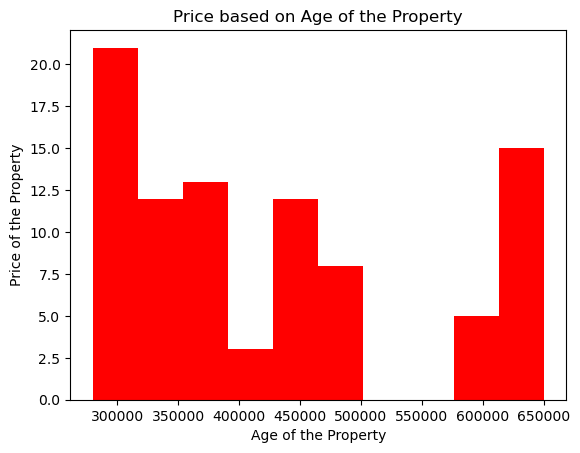

In [6]:
print(data.describe() )

# Visualize distribution (optional)
import matplotlib.pyplot as plt
plt.hist(data['price'], color="red")
plt.title("Price based on Age of the Property")
plt.xlabel("Age of the Property")
plt.ylabel("Price of the Property")
plt.show()

#### Clean the Data

In [10]:
# Check for missing values
print(data.isnull().sum())

# Handle missing values (if any)
data = data.dropna() # Drop rows with missing values (simplest approach)

bedrooms       0
bathrooms      0
sqft_living    0
age            0
price          0
year_built     0
dtype: int64


In [12]:
# Example: Create a new feature 'age' by subtracting 'year_built' from the current year
data['age'] = 2023 - data['year_built']

#### Run a Predictive Model

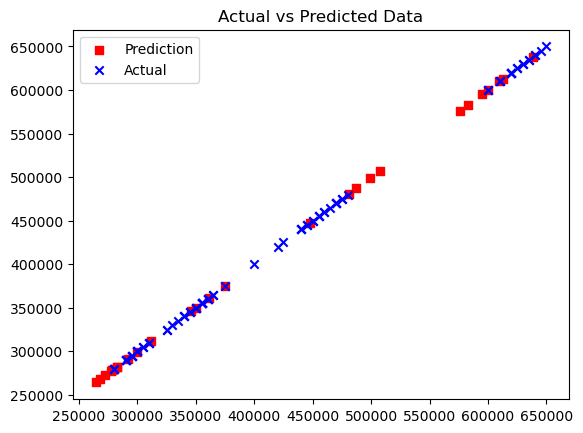

In [13]:
X = data[['bedrooms', 'bathrooms', 'sqft_living', 'age']] # Features
y = data['price'] # Target variable

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

plt.scatter(y_pred, y_pred, c='r', marker='s', label='Prediction')
plt.scatter(y,y, c='b', marker='x', label='Actual')

plt.legend(loc='upper left')
plt.title("Actual vs Predicted Data")
plt.show()

#### Acquire the Accurracy Scores

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 661520799.8356955
R-squared: 0.9636322824751818
